# Test
--------

This file is meant for implenting new ideas for code without affect the main.py file.

## Random walk of a single particle

The goal is to create a code that can produce a sigle random walk. After creating code, plot the trajectory of partcile on grid.

In [9]:
# Install required libraries libraries
%pip install numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import random

In [11]:
## Random walk of a single particle

# grid
grid_size_x, grid_size_y = 101, 101
x, y = grid_size_x// 2, grid_size_y // 2 # particle starts at center

# store trajectory in empty lists
x_pos, y_pos = [], []

steps = 10000

# particle movement
for i in range(steps):

    move_accepted = False

    # rejects invalid moves
    while not move_accepted:

        direction = random.choice(["up", "down", "right", "left"])

        # positions after choice
        dx, dy = x, y 

        if direction == "up":
            dy += 1
        elif direction == "down":
            dy -= 1
        elif direction == "right":
            dx += 1
        elif direction == "left":
            dx -= 1

        # ensures particles stays within grid
        if 0 <= dx < grid_size_x and 0 <= dy < grid_size_y:

            # Accept move
            x = dx
            y = dy

            # defines an accepted move
            move_accepted = True
    


    # store accepted positions
    x_pos.append(x)
    y_pos.append(y)


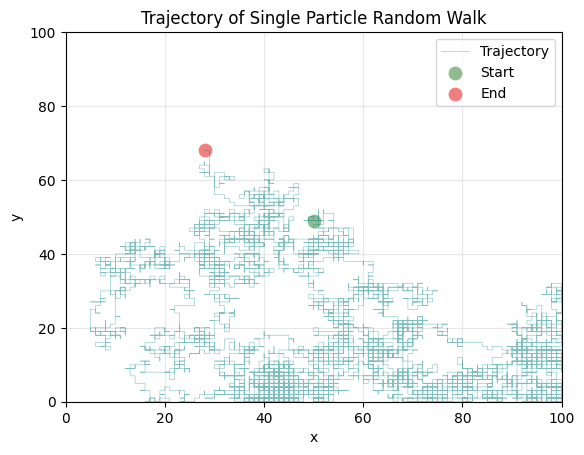

In [12]:
## Plot of trajectory

plt.figure()
plt.plot(
    x_pos,
    y_pos,
    lw=0.4,
    alpha=0.5,
    color="teal",
    label="Trajectory"
)

# starting point
plt.scatter(
    x_pos[0],
    y_pos[0],
    color="DarkSeaGreen",
    s=80,
    label="Start"
)

# ending point
plt.scatter(
    x_pos[-1],
    y_pos[-1],
    color="lightcoral",
    s=80,
    label="End"
)

plt.title("Trajectory of Single Particle Random Walk")
plt.xlim(0,grid_size_x - 1)
plt.ylim(0, grid_size_y - 1)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Random walk of multiple particles

Now the goal is to simulation a random walk of mutliple particles. Howeber, this time I also want to produce a heatmap for heat diffusion applications.

In [13]:
## random walk of multiple particles

#grid
grid_size_x, grid_size_y = 101, 101
N = 200 # number of particles

# alll particles start center
x = [grid_size_x // 2] * N
y = [grid_size_y // 2] * N

steps = 1000

# particle movement
for step in range(steps):

    # move every particle
    for i in range(N):

        move_accepted = False

        # rejects invalid moves
        while not move_accepted:

            direction = random.choice(["up", "down", "right", "left"])

            # positions after choice
            dx, dy = x[i], y[i]

            if direction == "up":
                dy += 1
            elif direction == "down":
                dy -= 1
            elif direction == "right":
                dx += 1
            elif direction == "left":
                dx -= 1

            # check bounds
            if 0 <= dx < grid_size_x and 0 <= dy < grid_size_y:

                # accept move
                x[i] = dx
                y[i] = dy

                move_accepted = True


    # store accepted positions
    x_pos.append(x)
    y_pos.append(y)



The code takees too long when N is large, so I pout my code through Claude.ai ans asked it to improve it (telling it the other goals as well) and it spit this out:

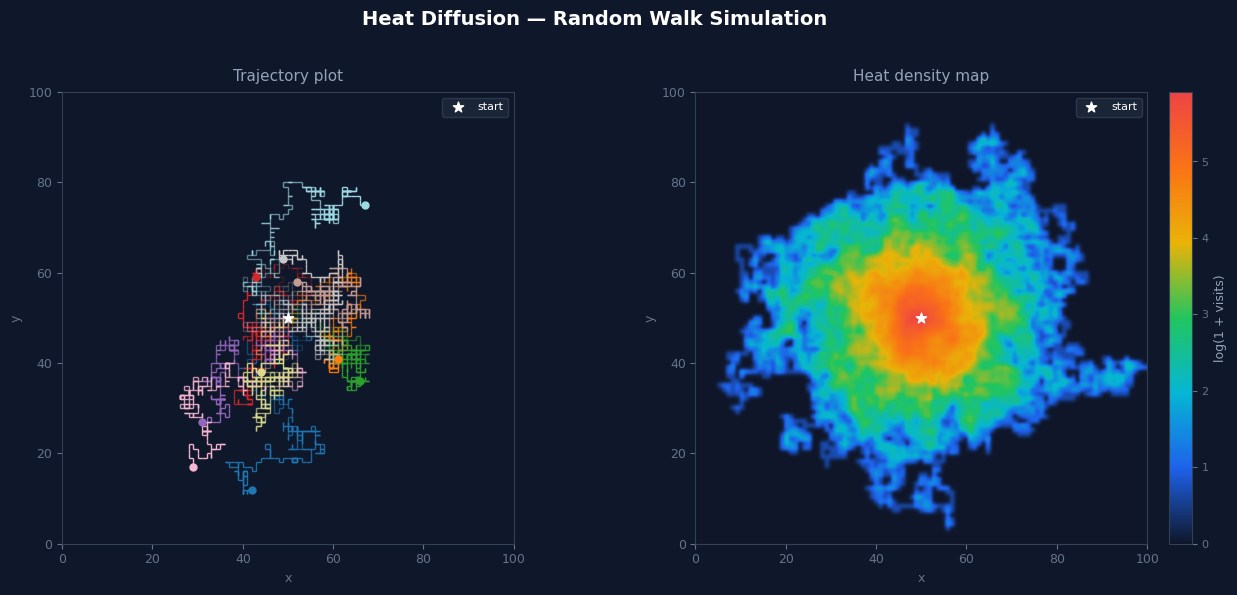

In [14]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection


# ── Parameters ─────────────────────────────────────────────────────────────────

grid_size_x, grid_size_y = 101, 101
N = 200         # number of particles
steps = 500     # number of steps each particle takes
n_trails = 10   # how many particle paths to draw on the trajectory plot

np.random.seed(42)

# center of the grid — all particles start here
center_x = grid_size_x // 2
center_y = grid_size_y // 2


# ── Set up starting positions ───────────────────────────────────────────────────

# every particle starts at the center
x = np.full(N, center_x, dtype=np.int32)
y = np.full(N, center_y, dtype=np.int32)

# heat[row, col] counts how many times any particle has visited that cell
heat = np.zeros((grid_size_y, grid_size_x))

# store the path of the first n_trails particles so we can draw them later
# each list starts at the center
traj_x = [[center_x] for _ in range(n_trails)]
traj_y = [[center_y] for _ in range(n_trails)]


# ── Possible moves ──────────────────────────────────────────────────────────────

# each row is one possible [dx, dy] step: up, down, right, left
directions = np.array([
    [ 0,  1],   # up
    [ 0, -1],   # down
    [ 1,  0],   # right
    [-1,  0],   # left
])


# ── Run the simulation ──────────────────────────────────────────────────────────

for step in range(steps):

    # pick a random direction for every particle at once
    chosen = directions[np.random.randint(0, 4, size=N)]

    # apply the moves
    new_x = x + chosen[:, 0]
    new_y = y + chosen[:, 1]

    # keep particles inside the grid (boundary = wall)
    np.clip(new_x, 0, grid_size_x - 1, out=new_x)
    np.clip(new_y, 0, grid_size_y - 1, out=new_y)

    x, y = new_x, new_y

    # add 1 to every cell a particle is currently sitting on
    # np.bincount counts how many particles share each cell index
    indices = y * grid_size_x + x
    heat += np.bincount(indices, minlength=grid_size_x * grid_size_y).reshape(grid_size_y, grid_size_x)

    # record the position of the trail particles
    for i in range(n_trails):
        traj_x[i].append(int(x[i]))
        traj_y[i].append(int(y[i]))


# ── Plot ────────────────────────────────────────────────────────────────────────

# one color per trail particle
trail_colors = plt.cm.tab20(np.linspace(0, 1, n_trails))

fig, (ax_traj, ax_heat) = plt.subplots(1, 2, figsize=(13, 6), facecolor="#0f172a")
fig.suptitle("Heat Diffusion — Random Walk Simulation",
             color="white", fontsize=14, fontweight="bold", y=0.98)

# dark background styling for both panels
for ax in (ax_traj, ax_heat):
    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334155")
    ax.tick_params(colors="#64748b", labelsize=9)


# left panel: trajectory plot ───────────────────────────────────────────────────

ax_traj.set_title("Trajectory plot", color="#94a3b8", fontsize=11, pad=8)
ax_traj.set_xlim(0, grid_size_x - 1)
ax_traj.set_ylim(0, grid_size_y - 1)
ax_traj.set_aspect("equal")
ax_traj.set_xlabel("x", color="#64748b", fontsize=9)
ax_traj.set_ylabel("y", color="#64748b", fontsize=9)

for i in range(n_trails):

    tx = np.array(traj_x[i])
    ty = np.array(traj_y[i])

    # build line segments so we can fade the trail from transparent to opaque
    points = np.array([tx, ty]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # alpha goes from 0.15 (oldest) to 1.0 (newest)
    alphas = np.linspace(0.15, 1.0, len(segments))
    colors = [(*trail_colors[i][:3], a) for a in alphas]

    lc = LineCollection(segments, colors=colors, linewidths=1.0)
    ax_traj.add_collection(lc)

    # dot at the particle's final position
    ax_traj.scatter(tx[-1], ty[-1], color=trail_colors[i], s=25, zorder=5)

# star at the starting point
ax_traj.scatter(center_x, center_y, color="white", s=60,
                marker="*", zorder=6, label="start")
ax_traj.legend(loc="upper right", fontsize=8,
               facecolor="#1e293b", labelcolor="white", edgecolor="#334155")


# right panel: heat density map ─────────────────────────────────────────────────

ax_heat.set_title("Heat density map", color="#94a3b8", fontsize=11, pad=8)
ax_heat.set_aspect("equal")
ax_heat.set_xlabel("x", color="#64748b", fontsize=9)
ax_heat.set_ylabel("y", color="#64748b", fontsize=9)

# custom colormap: dark navy → blue → cyan → green → yellow → orange → red
cmap_colors = [
    (0.059, 0.090, 0.165),   # dark navy  (cold)
    (0.118, 0.384, 0.922),   # blue
    (0.024, 0.714, 0.831),   # cyan
    (0.133, 0.773, 0.369),   # green
    (0.918, 0.702, 0.031),   # yellow
    (0.980, 0.451, 0.086),   # orange
    (0.937, 0.267, 0.267),   # red        (hot)
]
cmap = mcolors.LinearSegmentedColormap.from_list("heat", cmap_colors)

# log scale so faint low-visit areas are still visible
log_heat = np.log1p(heat)

im = ax_heat.imshow(log_heat, origin="lower", cmap=cmap,
                    interpolation="gaussian",
                    extent=[0, grid_size_x - 1, 0, grid_size_y - 1])

# color bar on the side
cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("log(1 + visits)", color="#94a3b8", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="#64748b", labelsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#64748b")
cbar.outline.set_edgecolor("#334155")

# star at the starting point
ax_heat.scatter(center_x, center_y, color="white", s=60,
                marker="*", zorder=5, label="start")
ax_heat.legend(loc="upper right", fontsize=8,
               facecolor="#1e293b", labelcolor="white", edgecolor="#334155")


# ── Save & show ─────────────────────────────────────────────────────────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("heat_diffusion.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

As you can see this is overly complicated. But I will take insperation from this code.

In [21]:
## random walk of multiple particles updates

#grid
grid_size_x, grid_size_y = 101, 101
N = 200 # number of particles

# center
center_x = grid_size_x // 2
center_y = grid_size_y // 2
# all particles start center
x = [center_x // 2] * N
y = [center_y // 2] * N

steps = 1000

# heat accumulation grid
heat = np.zeros((grid_size_y, grid_size_x))

# store trajectories for a few particles
traj_x = [[center_x] for _ in range(n_trails)]
traj_y = [[center_y] for _ in range(n_trails)]

# particle movement
for step in range(steps):

    # move every particle
    for i in range(N):

        move_accepted = False

        # rejects invalid moves
        while not move_accepted:

            direction = random.choice(["up", "down", "right", "left"])

            # positions after choice
            dx, dy = x[i], y[i]

            if direction == "up":
                dy += 1
            elif direction == "down":
                dy -= 1
            elif direction == "right":
                dx += 1
            elif direction == "left":
                dx -= 1

            # check bounds
            if 0 <= dx < grid_size_x and 0 <= dy < grid_size_y:

                # accept move
                x[i] = dx
                y[i] = dy

                move_accepted = True

        heat[y[i], x[i]] += 1


    # store trajectories for selected particles
    for j in range(n_trails):

        traj_x[j].append(x[j])
        traj_y[j].append(y[j])

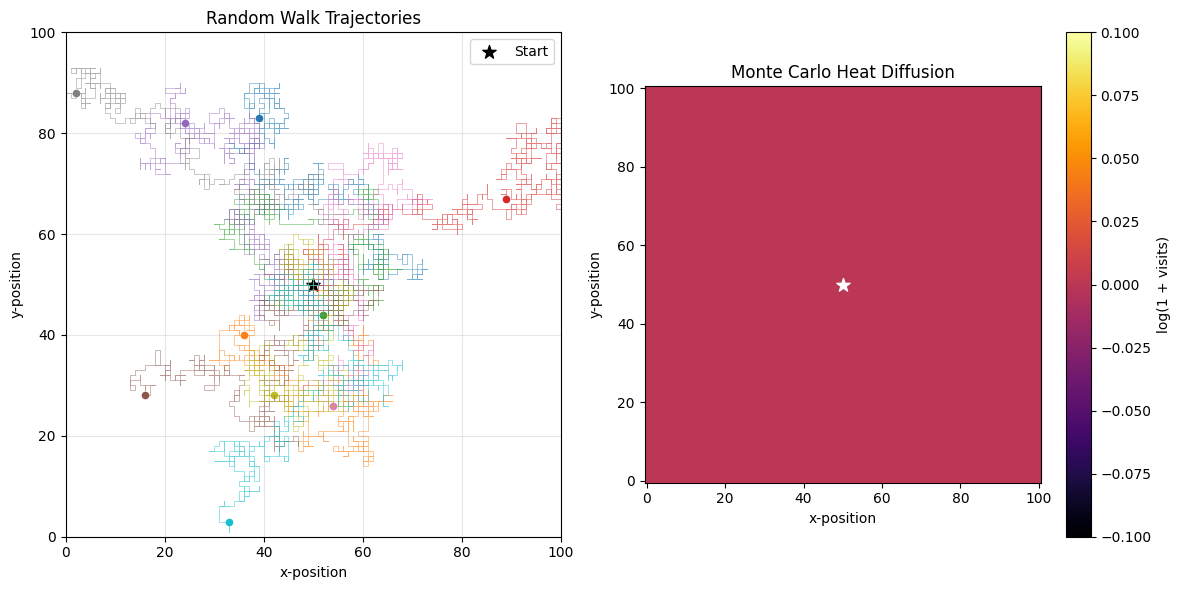

In [19]:
## plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Trajectory plot

for j in range(n_trails):

    ax1.plot(
        traj_x[j],
        traj_y[j],
        lw=0.5,
        alpha=0.6
    )

    # end point
    ax1.scatter(
        traj_x[j][-1],
        traj_y[j][-1],
        s=20
    )

# starting point
ax1.scatter(
    center_x,
    center_y,
    color="black",
    marker="*",
    s=100,
    label="Start"
)

ax1.set_title("Random Walk Trajectories")
ax1.set_xlabel("x-position")
ax1.set_ylabel("y-position")

ax1.set_xlim(0, grid_size_x - 1)
ax1.set_ylim(0, grid_size_y - 1)

ax1.grid(alpha=0.3)
ax1.legend()


# Heatmap

# logarithmic scaling
log_heat = np.log1p(heat)

im = ax2.imshow(
    log_heat,
    origin="lower",
    cmap="inferno",
    interpolation="gaussian"
)

ax2.set_title("Monte Carlo Heat Diffusion")
ax2.set_xlabel("x-position")
ax2.set_ylabel("y-position")

# starting point
ax2.scatter(
    center_x,
    center_y,
    color="white",
    marker="*",
    s=100
)

# colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("log(1 + visits)")

plt.tight_layout()
plt.show()